# E03. Evaluate Lineups
- This evaluates contest results
- Type: Evaluation
- Run Frequency: Irregular
- Sources:
    - DraftKings
- Created: 3/30/2024
- Updated: 4/24/2026

### Imports

In [1]:
# from DataImports import *
from U01Imports import *
from U02Functions import *

### Settings

In [2]:
start_date, end_date = "20250101", "20251231"  # Date range for game simulations
start_date, end_date = "20260101", "20261231"  # Date range for game simulations

contest_name = "Four-Seamer"                   # String in contest name
lineup_type = "Portfolio"                      # Accepts "Portfolio", "Field", "Lineups"

### Contests

In [3]:
contest_df = create_contests(start_date=start_date, end_date=end_date, name=contest_name, entryFee=None, exclusions=['vs', 'Turbo', '@'])

### Function

This assigns payouts and projected payouts to contest entries and my portfolio of possible entries

In [4]:
def evaluate_portfolio_lineups(contestKey, lineup_type):
    ### Portfolio Lineups
    def prepare_my_lineups(contestKey, lineup_type):
        # Select folder and file prefix
        if lineup_type == 'Portfolio':
            folder = "4. Portfolio Lineups"
            file_prefix = "Portfolio Lineups"
        elif lineup_type == "Field":
            folder = "3. Field Lineups"
            file_prefix = "Field Lineups"
        elif lineup_type == "Lineups":
            folder = "2. Lineups"
            file_prefix = "Lineups"

        # Read
        lineup_df = pd.read_csv(os.path.join(baseball_path, "C02. Optimization", folder, f"{file_prefix} {contestKey}.csv"))
        lineup_df = lineup_df.sort_values('FPPG', ascending=False).head(20)

        # Remove parentheses and numbers from player names in portfolio lineups to merge with player scores
        for col in lineup_df.select_dtypes(include='object').columns:
            lineup_df[col] = lineup_df[col].str.replace(r'\(\d+\)', '', regex=True)

        ### Player Results
        # Read
        player_score_df = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "6. Player Results", f"Player Results {contestKey}.csv"), usecols=['Player', 'FPTS', '%Drafted'], encoding='iso-8859-1')

        # Note: player_score_df contains name only in "Player" column, not "Name + ID," so we have to merge on name only. This can lead to some issues with duplicate names (Will Smith, for instance).
        # I'm defauling to picking the most likely player (using %Drafted) if there are duplicate names. This could perhaps be improved by pulling in position from Player Results and merging on name + position.
        # This wouldn't matter much, however. Even choosing the least likely or lowest scoring duplicate player barely matters.
        player_score_df = player_score_df.sort_values('%Drafted', ascending=False).drop_duplicates(subset=['Player'], keep='first')
        player_score_df.drop(columns=['%Drafted'], inplace=True)

        # For each position, merge the player's point total
        points_list = []
        for pos in ['P', 'P.1', 'C', '1B', '2B', '3B', 'SS', 'OF', 'OF.1', 'OF.2']:
            # Merges on name only, remove numeric characters
            lineup_df[pos] = lineup_df[pos].str.replace(r'[(0-9)]', "", regex=True)
            lineup_df[pos] = lineup_df[pos].str.rstrip()

            # Merge with points
            lineup_df = lineup_df.merge(player_score_df, left_on=pos, right_on='Player', how='left')
            points_name = 'FPTS' + "_" + pos
            points_list.append(points_name)
            lineup_df.drop(columns={'Player'},inplace=True)
            lineup_df.rename(columns={'FPTS':points_name},inplace=True)

        # Sum points across all positions for each lineup
        lineup_df['Points'] = lineup_df[points_list].sum(axis=1)
        # Add entry information
        lineup_df['EntryId'] = "Me"
        lineup_df['EntryName'] = "Me"
        lineup_df['TimeRemaining'] = 0
        lineup_df['Lineup'] = ""


        # Columns to return
        if lineup_type == "Portfolio":
            return_columns = ['EntryId', 'EntryName', 'TimeRemaining', 'Points', 'Lineup', 'P', 'P.1', 'C', '1B', '2B', '3B', 'SS', 'OF', 'OF.1', 'OF.2', 'Stack', 'EV_Payout', 'Top_1pct_rate', 'Top_5pct_rate']
        else:
            return_columns = ['EntryId', 'EntryName', 'TimeRemaining', 'Points', 'Lineup', 'P', 'P.1', 'C', '1B', '2B', '3B', 'SS', 'OF', 'OF.1', 'OF.2', 'Stack']


        return lineup_df[return_columns]

    # Run
    lineup_df = prepare_my_lineups(contestKey, lineup_type)


    ### Entry Results
    # Read
    entry_result_df = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "5. Entry Results", f"Entry Results {contestKey}.csv"), encoding='iso-8859-1')

    # Merge portfolio lineups with entry results
    all_lineup_df = pd.concat([lineup_df, entry_result_df], ignore_index=True)

    # Sort by Points descending and assign ranks
    all_lineup_df['Projected Rank'] = all_lineup_df['Points'].rank(method='min', ascending=False).astype(int)

    # Sort the DataFrame by rank
    all_lineup_df = all_lineup_df.sort_values('Projected Rank').reset_index(drop=True)


    ### Payouts
    # Read
    payout_df = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "3. Payouts", f"Payouts {contestKey}.csv"), encoding='iso-8859-1')

    # First, create a mapping of each position to its payout
    # For ranges, expand them into individual positions
    payout_mapping = {}
    for _, row in payout_df.iterrows():
        for pos in range(row['minPosition'], row['maxPosition'] + 1):
            payout_mapping[pos] = row['payoutDescription']

    # Calculate Actual Payouts
    # Now, assign a preliminary payout based on rank
    all_lineup_df['Payout'] = all_lineup_df['Rank'].map(payout_mapping)

    # Convert payoutDescription to numeric if needed
    all_lineup_df['Payout'] = all_lineup_df['Payout'].replace('[\$,]', '', regex=True).astype(float)

    # Group by rank to handle ties
    all_lineup_df['Payout'] = all_lineup_df.groupby('Rank')['Payout'].transform('mean')

    # Fill missing payouts with 0s
    all_lineup_df['Payout'] = all_lineup_df['Payout'].fillna(0)


    # Calculate Projected Payouts
    # Now, assign a preliminary payout based on rank
    all_lineup_df['Projected Payout'] = all_lineup_df['Projected Rank'].map(payout_mapping)

    # Handle ties: average the payouts for tied ranks
    # Convert payoutDescription to numeric if needed
    all_lineup_df['Projected Payout'] = all_lineup_df['Projected Payout'].replace('[\$,]', '', regex=True).astype(float)

    # Group by rank to handle ties
    all_lineup_df['Projected Payout'] = all_lineup_df.groupby('Projected Rank')['Projected Payout'].transform('mean')

    # Fill missing payouts with 0s
    all_lineup_df['Projected Payout'] = all_lineup_df['Projected Payout'].fillna(0)

    # Paid Binary
    all_lineup_df['Paid'] = (all_lineup_df['Payout'] > 0).astype(int)
    all_lineup_df['Projected Paid'] = (all_lineup_df['Projected Payout'] > 0).astype(int)

    ### Contest Guides
    # Read
    contest_guide_df = pd.read_csv(os.path.join(baseball_path, "B03. Contest Guides", f"Contest Guide {contestKey}.csv"), encoding='iso-8859-1')

    # Extract entry fee
    all_lineup_df['entryFee'] = float(contest_guide_df.loc[0, 'entryFee'])

    # Calculate ROI
    all_lineup_df['ROI'] = (all_lineup_df['Payout'] - all_lineup_df['entryFee']) / all_lineup_df['entryFee']
    all_lineup_df['Projected ROI'] = (all_lineup_df['Projected Payout'] - all_lineup_df['entryFee']) / all_lineup_df['entryFee']

    # Calculate percentile
    all_lineup_df['Projected Percentile'] = (1 - (all_lineup_df['Projected Rank'] - 1) / len(all_lineup_df))
    all_lineup_df['Projected 95th Percentile'] = (all_lineup_df['Projected Percentile'] >= 0.95).astype(int)
    all_lineup_df['Projected 99th Percentile'] = (all_lineup_df['Projected Percentile'] >= 0.99).astype(int)

    # Add contestKey
    all_lineup_df['contestKey'] = contestKey

    # Entrants
    all_lineup_df['Entrants'] = len(all_lineup_df)


    return all_lineup_df

### Sample

In [5]:
# Create list of contestKeys with available guides
guide_contestKey_list = os.listdir(os.path.join(baseball_path, "B03. Contest Guides"))
guide_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in guide_contestKey_list]

# Create list of contestKeys with available results
result_contestKey_list = os.listdir(os.path.join(baseball_path, "A09. DraftKings", "6. Player Results"))
result_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in result_contestKey_list]

# Create list of contestKeys with available Payouts
payout_contestKey_list = os.listdir(os.path.join(baseball_path, "A09. DraftKings", "3. Payouts"))
payout_contestKey_list = [int(key.replace(".csv", "").split(" ")[1]) for key in payout_contestKey_list]

# Create a list of contestKeys with field lineups
field_contestKey_list = os.listdir(os.path.join(baseball_path, "C02. Optimization", "3. Field Lineups"))
field_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in field_contestKey_list]

# Create a list of contestKeys with portfolio lineups
portfolio_contestKey_list = os.listdir(os.path.join(baseball_path, "C02. Optimization", "4. Portfolio Lineups"))
portfolio_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in portfolio_contestKey_list]

# Create a list of contestKeys with optimized lineups
lineup_contestKey_list = os.listdir(os.path.join(baseball_path, "C02. Optimization", "5. Lineups Ranked"))
lineup_contestKey_list = [int(key.replace(".csv", "").split(" ")[2]) for key in lineup_contestKey_list]

# Find the overlap
available_contestKey_list = list(set(result_contestKey_list) & set(guide_contestKey_list) & set(payout_contestKey_list) & set(field_contestKey_list) & set(portfolio_contestKey_list) & set(lineup_contestKey_list) & set(contest_df['contestKey'].astype(int).unique()))

### Run

In [6]:
%%time

contest_results_list = Parallel(n_jobs=-1, verbose=1)(delayed(evaluate_portfolio_lineups)(contestKey, lineup_type) for contestKey in available_contestKey_list)
all_contest_results_df = pd.concat(contest_results_list, axis=0)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


CPU times: total: 1.06 s
Wall time: 1.09 s


[Parallel(n_jobs=-1)]: Done 192 out of 192 | elapsed:    0.9s finished


In [7]:
all_contest_results_df.head()

,EntryId,EntryName,TimeRemaining,Points,Lineup,P,P.1,C,1B,2B,3B,SS,OF,OF.1,OF.2,Stack,EV_Payout,Top_1pct_rate,Top_5pct_rate,Rank,Projected Rank,Payout,Projected Payout,Paid,Projected Paid,entryFee,ROI,Projected ROI,Projected Percentile,Projected 95th Percentile,Projected 99th Percentile,contestKey,Entrants
0,5136562239,Robhill68,0,182.100000,1B Nick Kurtz 2B Ernie Clement 3B Kazuma Okamoto C Brandon Valenzuela OF Kyle Stowers OF Daulton Varsho OF Addison Barger P Chase Burns P Trey Yesavage SS Gunnar Henderson,Chase Burns,Trey Yesavage,Brandon Valenzuela,Nick Kurtz,Ernie Clement,Kazuma Okamoto,Gunnar Henderson,Kyle Stowers,Daulton Varsho,Addison Barger,NaN,NaN,NaN,NaN,1.000000,1,1500.000000,1500.000000,1,1,4.000000,374.000000,374.000000,1.000000,1,1,190319616,4470
1,5136376563,trom83 (1/4),0,177.650000,1B Nick Kurtz 2B Xavier Edwards 3B Kazuma Okamoto C Shea Langeliers OF George Springer OF Kyle Stowers OF Daulton Varsho P Trey Yesavage P Aaron Civale SS Ernie Clement,Trey Yesavage,Aaron Civale,Shea Langeliers,Nick Kurtz,Xavier Edwards,Kazuma Okamoto,Ernie Clement,George Springer,Kyle Stowers,Daulton Varsho,NaN,NaN,NaN,NaN,2.000000,2,750.000000,750.000000,1,1,4.000000,186.500000,186.500000,0.999776,1,1,190319616,4470
2,5136461436,jjjacquesjerry (4/5),0,172.900000,1B Luis Garcia Jr. 2B Ernie Clement 3B Kazuma Okamoto C Brandon Valenzuela OF James Wood OF Daylen Lile OF Addison Barger P Trey Yesavage P Janson Junk SS CJ Abrams,Trey Yesavage,Janson Junk,Brandon Valenzuela,Luis Garcia Jr.,Ernie Clement,Kazuma Okamoto,CJ Abrams,James Wood,Daylen Lile,Addison Barger,NaN,NaN,NaN,NaN,3.000000,3,500.000000,500.000000,1,1,4.000000,124.000000,124.000000,0.999553,1,1,190319616,4470
3,5136373975,sboynton10 (17/20),0,172.100000,1B Connor Norby 2B Xavier Edwards 3B Brady House C Joe Mack OF James Wood OF Kyle Stowers OF Jakob Marsee P Chase Burns P Trey Yesavage SS CJ Abrams,Chase Burns,Trey Yesavage,Joe Mack,Connor Norby,Xavier Edwards,Brady House,CJ Abrams,James Wood,Kyle Stowers,Jakob Marsee,NaN,NaN,NaN,NaN,4.000000,4,400.000000,400.000000,1,1,4.000000,99.000000,99.000000,0.999329,1,1,190319616,4470
4,5136636833,Juan1226 (12/20),0,172.100000,1B Connor Norby 2B Xavier Edwards 3B Brady House C Joe Mack OF James Wood OF Kyle Stowers OF Jakob Marsee P Chase Burns P Trey Yesavage SS CJ Abrams,Chase Burns,Trey Yesavage,Joe Mack,Connor Norby,Xavier Edwards,Brady House,CJ Abrams,James Wood,Kyle Stowers,Jakob Marsee,NaN,NaN,NaN,NaN,4.000000,4,400.000000,400.000000,1,1,4.000000,99.000000,99.000000,0.999329,1,1,190319616,4470


### Evaluate

##### My Lineups

In [8]:
if lineup_type == "Portfolio":
    summary_columns = ['entryFee', 'Paid', 'Projected Paid', 'Projected Payout', 'EV_Payout', 'Projected ROI', 'Projected Percentile', 'Projected 95th Percentile', 'Top_5pct_rate', 'Projected 99th Percentile', 'Top_1pct_rate']
else:
    summary_columns = ['entryFee', 'Paid', 'Projected Paid', 'Projected Payout', 'Projected ROI', 'Projected Percentile', 'Projected 95th Percentile', 'Projected 99th Percentile']

all_contest_results_df.query('EntryName == "Me"')[summary_columns].describe()

,entryFee,Paid,Projected Paid,Projected Payout,EV_Payout,Projected ROI,Projected Percentile,Projected 95th Percentile,Top_5pct_rate,Projected 99th Percentile,Top_1pct_rate
count,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000,3610.000000
mean,4.000000,0.000000,0.354017,4.709695,13.220479,0.177424,0.594435,0.081163,0.131490,0.017729,0.044939
std,0.000000,0.000000,0.478280,17.137455,7.280985,4.284364,0.273134,0.273124,0.036524,0.131981,0.021734
min,4.000000,0.000000,0.000000,0.000000,1.422852,-1.000000,0.001788,0.000000,0.025065,0.000000,0.006185
25%,4.000000,0.000000,0.000000,0.000000,8.557617,-1.000000,0.374762,0.000000,0.108398,0.000000,0.031250
50%,4.000000,0.000000,0.000000,0.000000,11.540527,-1.000000,0.630556,0.000000,0.126953,0.000000,0.040039
75%,4.000000,0.000000,1.000000,6.000000,15.893311,0.500000,0.835445,0.000000,0.150391,0.000000,0.052734
max,4.000000,0.000000,1.000000,500.000000,140.281250,124.000000,1.000000,1.000000,0.370117,1.000000,0.205078


##### T-Test

In [9]:
me_roi = all_contest_results_df.loc[
    all_contest_results_df['EntryName'] == 'Me',
    'Projected ROI'
]

t_stat, p_val = ttest_1samp(me_roi, 0)

print("Mean ROI:", me_roi.mean())
print("t-stat:", t_stat)
print("p-value (two-sided):", p_val)

# One-sided test (ROI > 0)
p_val_one_sided = p_val / 2 if t_stat > 0 else 1 - p_val / 2

print(f"N: {len(me_roi)}")
print(f"Mean ROI: {me_roi.mean():.4f}")
print(f"Std: {me_roi.std():.4f}")
print(f"t-stat: {t_stat:.3f}")
print(f"p-value (ROI>0): {p_val_one_sided:.4f}")

Mean ROI: 0.17742382271468143
t-stat: 2.488165093445432
p-value (two-sided): 0.012885192089627875
N: 3610
Mean ROI: 0.1774
Std: 4.2844
t-stat: 2.488
p-value (ROI>0): 0.0064


##### Stack Choice and Performance

In [10]:
(all_contest_results_df
        .groupby('Stack')['Projected ROI']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Projected ROI', 'count': 'Num Entries'})
        .sort_values('Projected ROI', ascending=False)
        .reset_index())

,Stack,Projected ROI,Num Entries
0,"(5, 2, 1)",0.337423,489
1,"(5, 3)",0.262567,935
2,"(4, 3, 1)",0.154183,514
3,"(5, 1, 1, 1)",0.101218,657
4,"(4, 4)",0.083005,1015


In [11]:
all_contest_results_df.query('EntryName == "Me"').query('`Projected Payout` > 100')

,EntryId,EntryName,TimeRemaining,Points,Lineup,P,P.1,C,1B,2B,3B,SS,OF,OF.1,OF.2,Stack,EV_Payout,Top_1pct_rate,Top_5pct_rate,Rank,Projected Rank,Payout,Projected Payout,Paid,Projected Paid,entryFee,ROI,Projected ROI,Projected Percentile,Projected 95th Percentile,Projected 99th Percentile,contestKey,Entrants
9,Me,Me,0,170.100000,,Trey Yesavage,Chase Burns,Drew Millas,Luis Garcia Jr.,Ernie Clement,Jose Tena,CJ Abrams,George Springer,Jesus Sanchez,James Wood,"(5, 3)",12.398438,0.040039,0.124023,NaN,10,0.000000,150.000000,0,1,4.000000,-1.000000,36.500000,0.997987,1,1,190319616,4470
1,Me,Me,0,104.850000,,Bryan Woo,Kyle Bradish,Dalton Rushing,Freddie Freeman,Cole Young,Max Muncy,Jared Triolo,Kyle Tucker,Shohei Ohtani,Dominic Canzone,"(5, 2, 1)",27.804688,0.086914,0.208008,NaN,2,0.000000,300.000000,0,1,4.000000,-1.000000,74.000000,0.999444,1,1,191246880,1797
2,Me,Me,0,185.850000,,Bryce Miller,Yoshinobu Yamamoto,Ben Rice,Freddie Freeman,Alex Freeland,Max Muncy,Jose Caballero,Cody Bellinger,Trent Grisham,Ryan Ward,"(4, 4)",14.494141,0.063477,0.131836,NaN,3,0.000000,125.000000,0,1,4.000000,-1.000000,30.250000,0.997365,1,1,190934583,759
8,Me,Me,0,183.200000,,Paul Skenes,Zack Wheeler,Carson Kelly,Kyle Manzardo,Nico Hoerner,Jose Ramirez,Brayan Rocchio,Chase DeLauter,Ian Happ,Michael Conforto,"(4, 4)",12.462891,0.036133,0.118164,NaN,9,0.000000,200.000000,0,1,4.000000,-1.000000,49.000000,0.998655,1,1,190547520,5946
0,Me,Me,0,166.850000,,Jared Jones,Jacob Misiorowski,Endy Rodriguez,TJ Rumfield,Willi Castro,Nick Gonzales,Jared Triolo,Esmerlyn Valdez,Cole Carrigg,Jake McCarthy,"(4, 4)",11.275391,0.053060,0.177409,NaN,1,0.000000,200.000000,0,1,4.000000,-1.000000,49.000000,1.000000,1,1,191896199,602
1,Me,Me,0,200.200000,,Ryan Weathers,Gage Jump,Salvador Perez,Alec Burleson,JJ Wetherholt,Nick Loftin,Bobby Witt Jr.,Juan Soto,Isaac Collins,Lane Thomas,"(5, 2, 1)",16.671224,0.041016,0.127604,NaN,2,0.000000,500.000000,0,1,4.000000,-1.000000,124.000000,0.999662,1,1,191452845,2959
2,Me,Me,0,147.150000,,Michael King,George Kirby,Will Smith,Pavin Smith,Ketel Marte,Alex Freeland,Mookie Betts,Alek Thomas,Kyle Tucker,Shohei Ohtani,"(5, 3)",9.519531,0.038086,0.127930,NaN,3,0.000000,150.000000,0,1,4.000000,-1.000000,36.500000,0.997805,1,1,189217989,911
1,Me,Me,0,155.650000,,Reynaldo Lopez,Robbie Ray,Drake Baldwin,Matt Olson,Luis Arraez,Austin Riley,Francisco Lindor,Jordan Lawlar,Mike Yastrzemski,Ronald Acuna Jr.,"(5, 1, 1, 1)",9.106445,0.031250,0.098633,NaN,2,0.000000,200.000000,0,1,4.000000,-1.000000,49.000000,0.998897,1,1,189364435,907
4,Me,Me,0,162.000000,,Tyler Glasnow,Bryan Woo,Will Smith,Nolan Schanuel,Oswald Peraza,Colt Keith,Zach Neto,Jorge Soler,Mike Trout,Ronald Acuna Jr.,"(5, 1, 1, 1)",15.953125,0.049805,0.151367,NaN,5,0.000000,150.000000,0,1,4.000000,-1.000000,36.500000,0.998662,1,1,189244124,2990
4,Me,Me,0,202.400000,,Sonny Gray,Drew Rasmussen,Drew Millas,Luis Garcia Jr.,Jorbit Vivas,Isaac Paredes,Jeremy Pena,Yordan Alvarez,Daylen Lile,James Wood,"(5, 3)",12.467773,0.036133,0.104492,NaN,5,0.000000,300.000000,0,1,4.000000,-1.000000,74.000000,0.999329,1,1,191075056,5960


In [12]:
all_contest_results_df.query('EntryName == "Me"').query('`Projected Payout` > 50').shape

(33, 33)

5-2-1 and 5-1-1 stacks tend to be chosen most often for the portfolio

##### Top Entrants

In [17]:
all_contest_results_df['Entrant'] = all_contest_results_df['EntryName'].str.replace(r'\(.*?\)', '', regex=True).str.strip()
min_entries = 1000  # minimum number of entries required

# Aggregate mean projected payout, mean payout, and count
summary_df = (
    all_contest_results_df
    .groupby('Entrant')
    .agg(
        **{
            'Mean Projected Payout': ('Projected Payout', 'mean'),
            'Mean Payout': ('Payout', 'mean'),
            'Mean Projected Paid': ('Projected Paid', 'mean'),
            'Mean Paid': ('Paid', 'mean'),
            'Mean Projected ROI': ('Projected ROI', 'mean'),
            'Mean ROI': ('ROI', 'mean'),
            'Mean Projected Percentile': ('Projected Percentile', 'mean'),
            'Mean Projected 95th Percentile': ('Projected 95th Percentile', 'mean'),
            'Mean Projected 99th Percentile': ('Projected 99th Percentile', 'mean'),
            'Mean Points': ('Points', 'mean'),
            'Num Entries': ('Projected Payout', 'count')
        }
    )
    .query('`Num Entries` >= @min_entries')  # filter by min_entries
    .sort_values('Mean Projected 95th Percentile', ascending=False)
    .reset_index()
)


# Predicted ROI based on average 95th Percentile rate for entrants
m, b = np.polyfit(summary_df['Mean Projected 95th Percentile'],
                  summary_df['Mean Projected ROI'], 1)
summary_df['Expected ROI'] = m * summary_df['Mean Projected 95th Percentile'] + b

summary_df

,Entrant,Mean Projected Payout,Mean Payout,Mean Projected Paid,Mean Paid,Mean Projected ROI,Mean ROI,Mean Projected Percentile,Mean Projected 95th Percentile,Mean Projected 99th Percentile,Mean Points,Num Entries,Expected ROI
0,Me,4.709695,0.000000,0.354017,0.000000,0.177424,-1.000000,0.594435,0.081163,0.017729,102.269114,3610,0.458932
1,cjcarlto,6.774623,6.796806,0.283052,0.284827,0.693656,0.699201,0.521270,0.077196,0.020408,97.209494,1127,0.387873
2,AstroPepper,3.849242,3.895455,0.268939,0.270455,-0.037689,-0.026136,0.509709,0.073485,0.021212,93.934811,1320,0.321401
3,BigMart11,4.715476,4.736905,0.288690,0.291071,0.178869,0.184226,0.526756,0.073214,0.020238,97.877173,1680,0.316555
4,DreamchaserJC,5.113303,5.124014,0.358512,0.359076,0.278326,0.281003,0.571497,0.071590,0.015220,101.765107,1774,0.287455
5,gilesj12,3.849171,3.894475,0.307735,0.311050,-0.037707,-0.026381,0.553651,0.071271,0.013812,98.969171,1810,0.281743
6,danvita50,4.460192,4.466317,0.284339,0.284339,0.115048,0.116579,0.518541,0.069991,0.011374,96.773491,1143,0.258827
7,smithbrandon7,6.461759,6.510516,0.275335,0.280115,0.615440,0.627629,0.529716,0.068834,0.013384,96.467639,1046,0.238093
8,wtfbra97,3.627451,3.650000,0.288235,0.290196,-0.093137,-0.087500,0.522059,0.068627,0.018627,98.018922,1020,0.234400
9,AverageTuesday,4.451873,4.486911,0.288764,0.291583,0.112968,0.121728,0.520222,0.068466,0.012485,96.577890,2483,0.231500


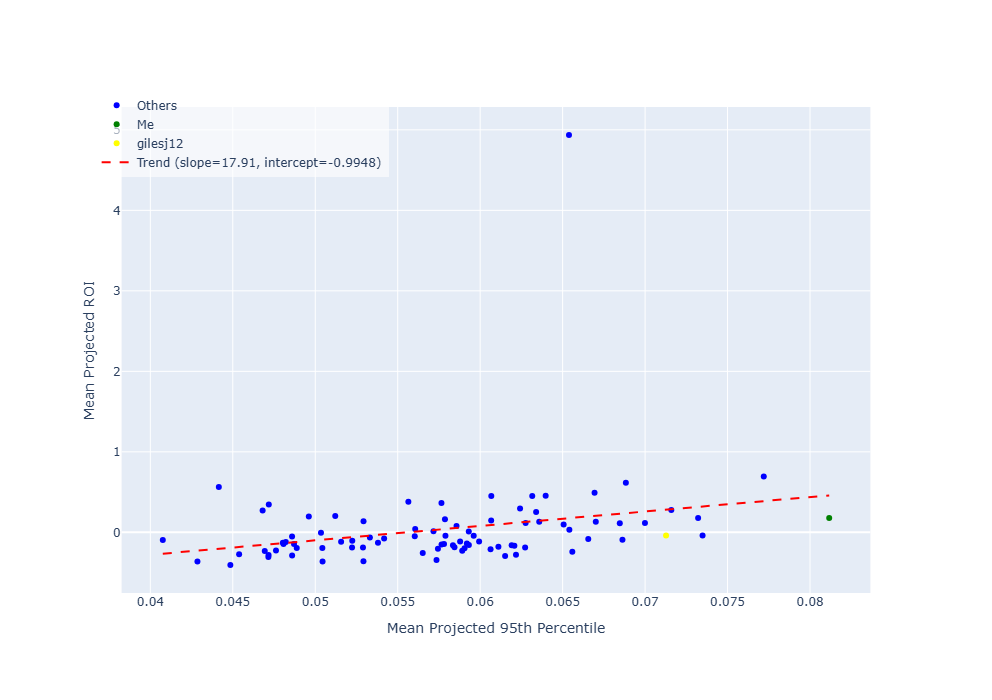

In [14]:
import plotly.graph_objects as go
import numpy as np

def get_color(entrant):
    if entrant == 'Me':
        return 'green'
    elif entrant == 'gilesj12':
        return 'yellow'
    else:
        return 'blue'

summary_df['color'] = summary_df['Entrant'].apply(get_color)


independent_variable = 'Mean Projected 95th Percentile'
dependent_variable = 'Mean Projected ROI'


fig = go.Figure()
for color, label in [('blue', 'Others'), ('green', 'Me'), ('yellow', 'gilesj12')]:
    subset = summary_df[summary_df['color'] == color]
    fig.add_trace(go.Scatter(
        x=subset[independent_variable],
        y=subset[dependent_variable],
        mode='markers',
        name=label,
        marker=dict(color=color),
        customdata=subset[summary_df.columns].values,
        hovertemplate='<br>'.join([f'{col}: %{{customdata[{i}]}}' for i, col in enumerate(summary_df.columns)])
    ))

x = summary_df[independent_variable]
y = summary_df[dependent_variable]
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b
fig.add_trace(go.Scatter(
    x=x_line, y=y_line, mode='lines',
    name=f'Trend (slope={m:.2f}, intercept={b:.4f})',
    line=dict(color='red', dash='dash')
))

fig.update_layout(
    width=700, height=700,
    margin=dict(l=80, r=80, t=80, b=80),
    xaxis=dict(title=independent_variable, domain=[0.05, 0.95]),
    yaxis=dict(title=dependent_variable, domain=[0.05, 0.95]),
    legend=dict(x=0.02, y=0.98, xanchor='left', yanchor='top',
                bgcolor='rgba(255,255,255,0.6)')
)
fig.show()

### Notes

Early testing shows that portfolios may perform better with:
- More field lineups
- More swap attempts for field lineups
- optimize_metric = "Top_5pct_rate" > "Top_1pct_rate"

Consider Adding:
- Optimized lineup support. Take lineups ranked version, top n by metric

Performance Tests:
- Field Lineups, unsorted, did poorly. Supports idea that I'm not just unilaterally overrating my lineups here, although this isn't definitive.
- Field Lineups, sorted, did great. Supports idea that my projections would have done very well in 2024 for determining lineup choice even if they weren't used in creation.
- Optimized Lineups, unsorted, did fantastic. Better than portfolio lineups, in fact. Not particularly bullish for the portfolio approach, but nice for the projections.

Conclusions:
- Code is likely correctly assigning ranks and payouts
- 2024 projections/lineups are very good. May be benefitting from too much insider information.
- Portfolio isn't definitively better than other approaches in this sample. Requires more testing.

I tried recalculating "Points" for other lineups the same way I do my own and it changed nothing. Just a few Max Muncy discrepancies.